In [1]:
# 1.导入三方库：pands、sklearn、matplotlib
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor # K近邻
import matplotlib.pyplot as plt

In [2]:
# 2. 读取数据：日期设为索引，只取最后1000个交易日的收盘价
df = pd.read_csv('stock_data.csv', index_col='Date', usecols=['Date','Close'])[-1000:]
df.head()

,Close
Date,
2021/6/29,133.415100
2021/6/30,134.031647
2021/7/1,134.335022
2021/7/2,136.967514
2021/7/6,138.983459


In [3]:
# 3. 准备训练（X）和预测（y）数据集 -- 用昨天的收盘价预测今天的收盘价
X = df[:-1]
y = df[1:]
X,y

(                Close
 Date                 
 2021/6/29  133.415100
 2021/6/30  134.031647
 2021/7/1   134.335022
 2021/7/2   136.967514
 2021/7/6   138.983459
 ...               ...
 2025/6/13  196.449997
 2025/6/16  198.419998
 2025/6/17  195.639999
 2025/6/18  196.580002
 2025/6/20  201.000000
 
 [999 rows x 1 columns],
                 Close
 Date                 
 2021/6/30  134.031647
 2021/7/1   134.335022
 2021/7/2   136.967514
 2021/7/6   138.983459
 2021/7/7   141.478973
 ...               ...
 2025/6/16  198.419998
 2025/6/17  195.639999
 2025/6/18  196.580002
 2025/6/20  201.000000
 2025/6/23  201.500000
 
 [999 rows x 1 columns])

In [4]:
# 4. 划分训练集和测试集：后20%作为测试 --> 观察误差
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [5]:
# 5. 创建模型
model = KNeighborsRegressor(n_neighbors=5)  # 使用5个最近邻

In [6]:
# 6. 训练模型
model.fit(X, y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
# 7. 预测模型
y_pred = model.predict(X_test)
y_pred[:5]

array([[222.7522522 ],
       [222.5203064 ],
       [221.43587036],
       [222.5203064 ],
       [222.5203064 ]])

Text(0.5, 1.0, 'KNeighborsRegressor')

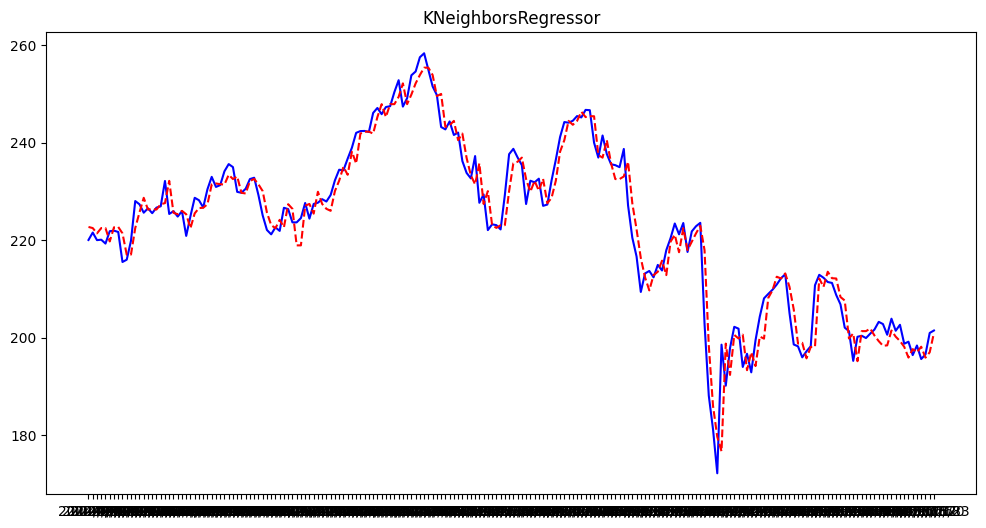

In [8]:
# 8. 可视化
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='y_test', color='blue')
plt.plot(y_pred, label='y_pred', color='red', linestyle='--')
plt.title('KNeighborsRegressor')